# Session 1 · Part 3 — Programming Model: NetQMPI Basics

**14:00 – 14:30**

---

Everything from **notebook 02** carries over. It does not carry over for free: four
properties we took for granted stop being true, and every design decision in
NetQMPI follows from those four breakages.

| MPI assumes | In the quantum case |
|---|---|
| You can copy a value | **No-cloning theorem.** An unknown state cannot be duplicated. `Bcast` is not slow — it is *forbidden*. |
| Reading does not destroy | Measurement collapses the state. There is no "inspect the buffer without consuming it". |
| The channel is reusable | Every transfer **consumes** an entangled pair. Bandwidth is an inventory, not a rate. |
| A late message is still valid | Entanglement **decoheres**. A correct-but-slow protocol can be a wrong protocol. |

One thing that does *not* change: **teleportation needs classical
communication.** Moving a qubit consumes a pre-shared EPR pair, the sender makes
a Bell measurement, and sends **two classical bits**. Without those two bits the
receiver cannot apply the right Pauli correction and holds garbage. A quantum
network is always a double network — a quantum plane distributing entanglement,
and a classical plane carrying measurement outcomes.

## The map from MPI to NetQMPI

Recall the copy / move / combine classification from notebook 02. It predicts
exactly what survives:

| MPI | NetQMPI | Why |
|---|---|---|
| `Send` / `Recv` | `qsend` / `qrecv` | Direct. Teleportation underneath; the original is destroyed, so no-cloning is respected. |
| `Scatter` / `Gather` | `qscatter` / `qgather` | Direct. They **move**, they do not copy. |
| `Bcast` | — | **Impossible.** Its functional role is taken by `expose`, with different semantics: it *spreads* a state, it does not replicate it. |
| `Reduce` | — | Would need a measurement to obtain combinable values, destroying the superposition. |

`qsend(qubit, dest_rank)` hides the entire teleportation protocol: EPR pair
generation, the local Bell measurement, sending two classical bits, and the
Pauli corrections at the receiver. Four steps, one call.

---
## 1 · The programming model

NetQMPI has a **decoupled architecture**: a user-facing SDK that is completely
backend-agnostic, and a Runtime that plugs in a concrete execution engine. The
same unmodified script runs on a quantum-network simulator, on an HPC vQPU
emulator, or on a plain circuit simulator — you change a command-line flag,
nothing else.

| Backend | Flag | What it targets |
|---|---|---|
| NetQASM / SquidASM | `--netqasm` | Low-level quantum-network simulation |
| **CUNQA** | `--cunqa` | **HPC emulation through virtual QPUs — what we use today** |
| Qiskit Aer | `--aer` | Shot-based circuit simulation |
| Qoala | `--qoala` | Quantum-internet node execution environment |

> ⚠ This image ships **only the CUNQA backend** — the NetQASM and Qoala backends were left out deliberately, because they need NetSquid from a credentialed private index.

Three SDK abstractions are all you need:

- **`Environment`** — the local node's context, and a factory for circuits. It
  arrives as the `env` argument of your `main()`.
- **`Circuit`** — a fluent, **index-based** API. You do not hold qubit objects;
  you refer to qubit `0`, qubit `1`, and so on. Operations are *recorded*, not
  executed immediately.
- **`QMPICommunicator`** — `env.comm`. Gives you `rank`, `size`, the neighbour
  helpers, and the communication primitives.

Two structural points that catch people out:

**`with comm:` is where execution happens.** Everything inside the block is
recorded into an operation container; leaving the block is what dispatches it to
the backend. Results are read *after* the block, from `comm.results`.

Because the whole group is dispatched in one go, **only the last rank to leave
the block receives the results — and it receives everyone's.** Every other rank
sees an empty `comm.results`. That is why each program below ends with the same
three lines, and why the output arrives as one block of `rank_N: {...}` rather
than one line per process the way `mpirun` gave you in notebook 02.

**Ranks are a ring.** `comm.get_next_rank(rank)` and `comm.get_prev_rank(rank)`
give you your neighbours, wrapping around. That is the idiom the examples use
instead of hard-coding `0` and `1`.

Run this first and read the output carefully. It tells you the exact flags this
build expects.

In [4]:
# EXAMPLE — what does the installed netqmpi understand?
!netqmpi --help

usage: netqmpi [-h] -n NUM_PROCS [--netqasm | --cunqa | --aer | --qoala]
               [--shots SHOTS] [--config CONFIG]
               script

Run a NetQMPI Python code.

positional arguments:
  script                Path to the NetQMPI Python script to be executed

options:
  -h, --help            show this help message and exit
  -n NUM_PROCS, --num-procs NUM_PROCS
                        Number of parallel processes
  --netqasm             Use NetQASM backend
  --cunqa               Use CUNQA backend
  --aer                 Use Qiskit AerSimulator backend
  --qoala               Use Qoala backend (simulation only)
  --shots SHOTS         Number of shots (overrides the value in --config, if
                        any)
  --config CONFIG       Path to a YAML config file with generic settings and
                        an optional per-backend block (e.g. a 'qoala:' block
                        with link_fidelity and a 'hardware' qdevice section).
                        Replaces pe

---
## 2 · Raising virtual QPUs

Just run the following cell to reserve the resources using CUNQA. No need to understand it right now, it will be explained in detail in the second session, when we cover the CUNQA emulator.

In [1]:
# Free resources
!qdrop --all

# Deploy two virtual QPUs, co-located on this single node.
from cunqa.qpu import qraise, get_QPUs

family = qraise(2, "01:30:00", simulator="Aer", co_located=True, quantum_comm=True)
print("family:", family)

Requested QPUs with command:
	qraise -n 2 -t 01:30:00 --quantum_comm --simulator=Aer --co-located
QPUs ready to work ✅
family: 11


In [ ]:
# They are scheduler jobs. Confirm they are running before going further.
!squeue

---
## 3 · Point-to-point: `qsend` and `qrecv`

Compare this with `p2p_demo.py` from notebook 02. Same rank-based branching,
same send/receive pair. That symmetry is deliberate: **if you can read MPI, you
can read this.**

In [ ]:
%%writefile qp2p_demo.py
from netqmpi.sdk.environment import Environment


def main(env: Environment = None):
    comm = env.comm
    rank = comm.rank

    next_rank = comm.get_next_rank(rank)
    previous_rank = comm.get_prev_rank(rank)

    with comm:                    # leaving this block runs it on the backend
        circuit = env.create_circuit(num_qubits=1, num_clbits=1)
        if rank == 0:
            circuit.h(0)                          # prepare |+>
            comm.qsend(circuit, [0], next_rank)   # teleport qubit 0
        else:
            comm.qrecv(circuit, [0], previous_rank)
            circuit.measure(0, 0)

    # Only the last rank out of the block holds the results, and it holds
    # everyone's.
    if comm.results:
        for other, counts in comm.results.items():
            print(f"rank_{other}: {counts}")

In [ ]:
!netqmpi -n 2 qp2p_demo.py --cunqa --shots 1024

**What those two lines hid.** `qsend` performed: EPR pair generation with the
neighbour, a local Bell measurement, transmission of two classical bits, and on
the receiving side the conditional `X` and `Z` corrections. The original qubit at
rank 0 no longer exists — the measurement destroyed it. The state *moved*.

We sent |+⟩, so `rank_1`'s counts should be roughly half `0` and half `1` over
1024 shots. `rank_0` reports almost nothing: teleportation *moves* a state, so
its data qubit is back in `|0>` by the end and its only measurements are the
protocol's own.

**Try it with a known state instead.** Change `circuit.h(0)` to `circuit.x(0)`
and re-run: rank 1 should now measure `1` on essentially every shot. That is a
much better test of whether teleportation actually worked — a 50/50 result is
also what you would get from a broken channel returning noise.

### Exercise 4 — A distributed Bell state between two ranks

Build $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ with **one
qubit on each rank**.

The recipe is the familiar one — Hadamard, then CNOT — with a twist: the two
halves must end up on different ranks. Build the pair *locally* first, then
teleport one half across.

In [ ]:
%%writefile ex4_bell.py
from netqmpi.sdk.environment import Environment


def main(env: Environment = None):
    comm = env.comm
    rank = comm.rank

    next_rank = comm.get_next_rank(rank)
    previous_rank = comm.get_prev_rank(rank)

    with comm:
        if rank == 0:
            # TODO 1: this rank needs TWO qubits and two classical bits.
            circuit = None   # TODO

            # TODO 2: build the Bell pair locally.
            #         Hadamard on qubit 0, then CNOT control 0, target 1.

            # TODO 3: teleport the SECOND half to the next rank, keeping the first.
            #         After this line the entanglement spans two ranks.

            circuit.measure(0, 0)
        else:
            circuit = env.create_circuit(num_qubits=1, num_clbits=1)

            # TODO 4: receive the half that rank 0 sent, onto local qubit 0.

            circuit.measure(0, 0)

    # Only the last rank out of the block holds the results, and it holds
    # everyone's.
    if comm.results:
        for other, counts in comm.results.items():
            print(f"rank_{other}: {counts}")

In [ ]:
!netqmpi -n 2 ex4_bell.py --cunqa --shots 1024

**Read the output carefully, because it is a trap.**

Each rank reports roughly 50% `0` and 50% `1`. That is *exactly* what you would
see if the two qubits were independent coin flips. A marginal distribution
cannot tell a Bell state from two unrelated random bits.

This is not a limitation of the exercise — it is a real and important property of
distributed entanglement: **the correlation lives in the joint distribution, and
neither node holds it.** To observe it you must either bring the two halves back
together, or do classical post-processing on shot-matched outcomes from both
ranks. The next cell does the first of those — a variant that teleports *both*
halves to rank 1 — and its counts show only `00` and `11`, never `01` or `10`.

In [ ]:
%%writefile bell_joint_demo.py
from netqmpi.sdk.environment import Environment


def main(env: Environment = None):
    comm = env.comm
    rank = comm.rank

    next_rank = comm.get_next_rank(rank)
    previous_rank = comm.get_prev_rank(rank)

    with comm:
        if rank == 0:
            circuit = env.create_circuit(num_qubits=2, num_clbits=2)
            circuit.h(0)
            circuit.cx(0, 1)
            comm.qsend(circuit, [1], next_rank)    # first half
            comm.qsend(circuit, [0], next_rank)    # and the second one too
        else:
            circuit = env.create_circuit(num_qubits=2, num_clbits=2)
            comm.qrecv(circuit, [0], previous_rank)
            comm.qrecv(circuit, [1], previous_rank)
            circuit.measure(0, 0)
            circuit.measure(1, 1)

    # Only the last rank out of the block holds the results, and it holds
    # everyone's.
    if comm.results:
        for other, counts in comm.results.items():
            print(f"rank_{other}: {counts}")

In [ ]:
!netqmpi -n 2 bell_joint_demo.py --cunqa --shots 1024

---
## 4 · Non-local operations and distributed gates

Moving a qubit is not always what a distributed algorithm needs. Often several
ranks only want to apply gates **controlled by a remote qubit** — the crossing
rotations of a QFT, for instance. Teleporting the control over and back costs two
transfers and drags any entanglement it already has with it.

The alternative is **telegate**: the qubit stays where it is and is *lent* to the
others through a shared GHZ state.

`expose` and `unexpose` are **collective**, like `MPI_Bcast`: every rank of the
window must call them, and `root` names the rank lending the qubit. The call
returns **the index each rank must use as the control** — its own data qubit on
the root, a freshly reserved communication qubit on every receiver — so the gate
itself is written exactly like a local one.

> **`unexpose` is mandatory, not polite.** Communication qubits and the classical
> bits carrying the protocol corrections are reserved when a window opens and
> released when it closes. Think of the pair as acquire/release on a lock, not as
> a broadcast.

### What `expose` and `unexpose` actually do

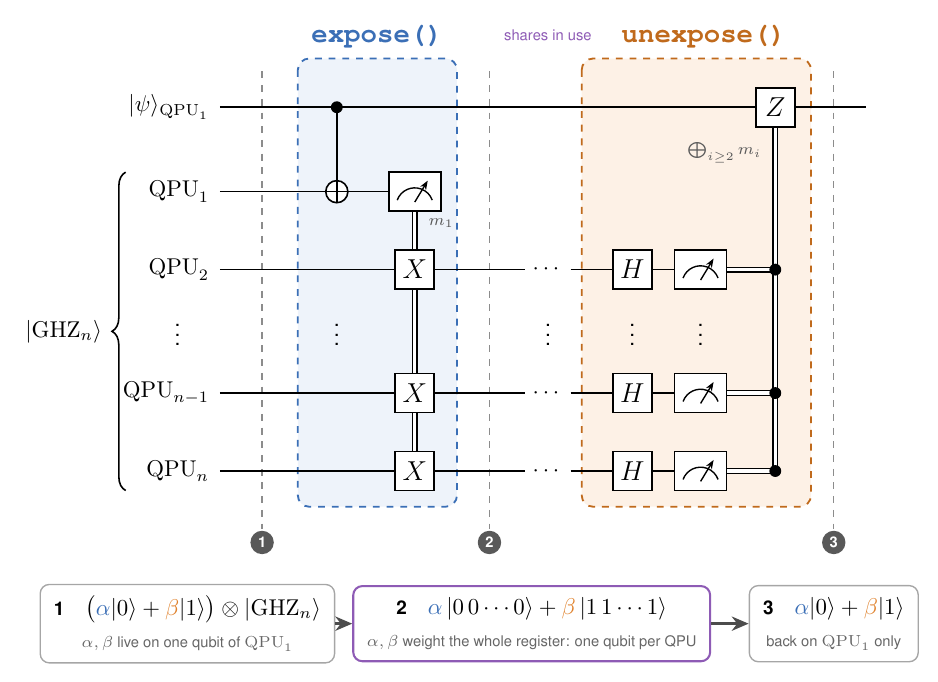

**How to read the figure.**

- The **top wire** is the qubit being lent: the data qubit of the root.
  $\mathrm{QPU}_1$ is the root (`root=0` in the code); $\mathrm{QPU}_2 \dots \mathrm{QPU}_n$
  are the other ranks.
- The wires **below it** are *communication qubits*, one on each QPU. Before the
  window opens they already share a GHZ state,
  $|\mathrm{GHZ}_n\rangle = \frac{1}{\sqrt{2}}\left(|00\cdots0\rangle + |11\cdots1\rangle\right)$.
- The **blue box** is `expose`, the **orange box** is `unexpose`. Single lines carry
  qubits; double lines carry classical bits.
- The dashed lines **1**, **2** and **3** mark three moments where we stop and look
  at the state. The strip at the bottom shows it, with $\alpha$ in blue and
  $\beta$ in orange so you can follow where the amplitudes go.

---

#### Step 1 — Before `expose`

$$\bigl(\alpha|0\rangle + \beta|1\rangle\bigr) \otimes |\mathrm{GHZ}_n\rangle$$

The state we want to lend, $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$, lives on
**one qubit of one QPU**. The GHZ state is a separate resource: it is entangled
across all the QPUs, but it knows nothing about $\alpha$ or $\beta$ yet.

#### From 1 to 2 — what `expose` does

1. **CNOT** from $|\psi\rangle$ onto the root's GHZ qubit ($\mathrm{QPU}_1$). This ties
   the value of $|\psi\rangle$ to the GHZ register.
2. **Measure** that GHZ qubit and get a bit $m_1$. It only says whether the bit of
   $|\psi\rangle$ and the bit of the GHZ state *were equal or different*. It says
   nothing about $\alpha$ or $\beta$, so the superposition survives.
3. **Send $m_1$** (one classical bit) to every other rank. If $m_1 = 1$, every
   receiver applies an **X** to its GHZ qubit, so that all of them agree with
   $|\psi\rangle$ again.

#### Step 2 — The qubit is exposed

$$\alpha\,|00\cdots0\rangle + \beta\,|11\cdots1\rangle$$

The register now has **exactly one qubit per QPU**: $|\psi\rangle$'s own qubit on the
root, and the corrected communication qubit on each receiver. These are the
indices `expose` returns to each rank.

Look at where $\alpha$ and $\beta$ went. They did **not** travel to each QPU.
They now weight the two branches of the *whole register*: in one branch every
QPU holds `0`, in the other every QPU holds `1`. No single QPU holds the state.
This is why `expose` is not a broadcast: a copy would be
$\bigl(\alpha|0\rangle + \beta|1\rangle\bigr)^{\otimes n}$, which no-cloning forbids.

What makes this useful is that **every share behaves as the control**. A gate
controlled by the share on rank $k$ does nothing in the $|0\cdots0\rangle$ branch
and fires in the $|1\cdots1\rangle$ branch, which is exactly what a CNOT controlled
by $|\psi\rangle$ itself would do. That is the `circuit.cx(control, 0)` line in
the next cell.

> **Treat the window as read-only.** While it is open, use the shares as controls.
> The root may also apply gates that are diagonal in the computational basis
> (`z`, `s`, `t`, `rz`). A gate like `h` or `x` on the root's qubit changes the
> branches on one QPU but not on the others, so the shares stop matching it.
> Put those gates before `expose` or after `unexpose`.

#### From 2 to 3 — what `unexpose` does

1. Every receiver applies **H** to its share and **measures** it, getting a bit
   $m_i$. After an H, both branches give `0` or `1` with the same probability, so
   this measurement removes the qubit *without* revealing which branch we are in.
2. It does leave a trace: each outcome $m_i = 1$ flips the sign between the two
   branches, $\alpha|0\rangle - \beta|1\rangle$. Two flips cancel out, so only
   the **parity** of all outcomes matters.
3. Every receiver **sends $m_i$** back to the root. If the parity
   $\bigoplus_{i\ge 2} m_i$ is 1, the root applies **Z**, which removes the
   leftover minus sign.

#### Step 3 — The window is closed

$$\alpha|0\rangle + \beta|1\rangle$$

The amplitudes are back on **one qubit of the root**, exactly as they started.
The communication qubits have been measured and released, and the GHZ state has
been consumed: one GHZ state per window.

If some rank applied controlled gates during the window, their effect stays. The
targets remain entangled with $|\psi\rangle$ exactly as if the control had been a
local qubit. Only the lending machinery disappears.

**Cost of one window.** One GHZ state; one classical bit from the root to every
receiver in `expose`; one classical bit from every receiver back to the root in
`unexpose`. Once again, a quantum plane and a classical plane working together.


In [ ]:
%%writefile expose_demo.py
from netqmpi.sdk.environment import Environment

def main(env: Environment = None):
    comm = env.comm
    rank = comm.rank

    with comm:
        circuit = env.create_circuit(num_qubits=1, num_clbits=1)

        # Rank 0 expose its qubit 0 and rank 1 receives the index to use.
        control = comm.expose(circuit, 0, [0,1], root=0)

        if rank == 0:
            circuit.h(0)
        elif rank == 1:
            circuit.cx(control, 0)     # controlled-X driven by a REMOTE qubit

        comm.unexpose(circuit, [0,1], root=0)   # the control goes back untouched

        circuit.measure(0, 0)

    # Only the last rank out of the block holds the results, and it holds
    # everyone's.
    if comm.results:
        for other, counts in comm.results.items():
            print(f"rank_{other}: {counts}")

In [ ]:
!netqmpi -n 2 expose_demo.py --cunqa --shots 1024

### Exercise 5 — A non-local CNOT across two QPUs

Apply `CNOT(control = a qubit on rank 0, target = a qubit on rank 1)` **without
moving either data qubit**.

Unlike exercise 4, this one is *directly verifiable*. Put the control in a
definite state: if rank 0's control is |1⟩, rank 1's target must flip to |1⟩ on
every shot. If the control is |0⟩, the target stays at `0`. No 50/50 ambiguity —
the answer is either right or wrong.

In [ ]:
%%writefile ex5_nonlocal_cnot.py
from netqmpi.sdk.environment import Environment

ROOT = 0


def main(env: Environment = None):
    comm = env.comm
    rank = comm.rank

    with comm:
        circuit = env.create_circuit(num_qubits=1, num_clbits=1)

        if rank == ROOT:
            circuit.x(0)                              # control = |1>

        # TODO 1: ROOT lends its qubit 0 to every rank of the communicator.
        #         `expose` is collective, so it sits OUTSIDE the `if` — and it
        #         returns the index each rank must use as the control.
        control = None   # TODO

        # TODO 2: every rank except ROOT applies the CNOT, driven by the
        #         borrowed control, onto its own qubit 0.

        # TODO 3: close the window. Mandatory: it releases the comm qubit and
        #         the protocol clbits, like a lock.

        circuit.measure(0, 0)

    # Only the last rank out of the block holds the results, and it holds
    # everyone's.
    if comm.results:
        for other, counts in comm.results.items():
            print(f"rank_{other}: {counts}")


In [ ]:
!netqmpi -n 2 ex5_nonlocal_cnot.py --cunqa --shots 1024

**How to know it worked.** Rank 1 must report `1` on essentially every shot.
Then delete the `circuit.x(0)` line and re-run: rank 1 must report `0` on
essentially every shot. The target follows a control that is on another machine
and never moved.

**Why bother, if exercise 4 reached a similar state?** Two reasons, and both cut
the same way:

- Exercise 4 **moved** a qubit. If that qubit had been entangled with a local
  computation, moving it would have dragged all of that along.
- Exercise 5 **generalises**. `expose` lends to the whole communicator, not to
  one partner. The same source with `-n 3` gives you a three-party controlled
  operation — change one number on the command line, touch nothing in the file.

That is the SPMD promise from notebook 02, holding all the way up through the
quantum layer.

---
## 5 · Release the resources

vQPUs are scheduler allocations. Leaving them up holds the reservation.

In [ ]:
!qdrop --all
!squeue

---
## If something failed

NetQMPI ships a directory of programs that are **meant** to fail, one failure
mode each, with a runner that reports what the library says about every one of
them — and it needs no vQPU at all. It is the fastest way to learn what the error
messages mean:

```bash
python examples/frequent_errors/run_all.py
```

Quick triage for today:

| Symptom | Likely cause |
|---|---|
| "no vQPUs up", run stops before building | `qraise` was never run, or the family was dropped |
| Run never finishes | Statevector simulator on oversized vQPUs — see the warning in section 2 |
| Hangs with some ranks idle | Fewer vQPUs raised than ranks requested |
| `co_located` mismatch | The flag must match how the vQPUs were raised |